# Tuning, Combining, and Testing

This notebook continues from part3_three_models notebook,
which built three models on the same 337-dim mahjong discard-decision feature set:
Logistic Regression, Random Forest (both supervised, predicting the discarded tile
type), and K-Means (unsupervised, segmenting decisions into strategic archetypes).

**recap (validation-set results):**

| Model | Val accuracy / silhouette |
|---|---|
| Random-among-legal baseline | ~18% |
| Logistic Regression (C=0.1) | ~60.8% |
| Random Forest (100 trees, depth 20) | ~50.1% |
| K-Means (k=5, on 20-component PCA) | silhouette ~0.12 |


## Setup: reload the same data, features, and splits used in part3_three_models notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score

np.random.seed(42)

def find_dir(name, candidates=(".", "/home/claude", "/mnt/user-data/outputs")):
    for d in candidates:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find {name}")

CACHE_DIR = find_dir("cache_100k")

X = np.load(os.path.join(CACHE_DIR, "X.npy"))
y = np.load(os.path.join(CACHE_DIR, "y.npy"))
masks = np.load(os.path.join(CACHE_DIR, "masks.npy"))
rounds = np.load(os.path.join(CACHE_DIR, "rounds.npy"))

# Reuse the exact same train/val/test split saved by Part 3
# test_mask was not touched in the previous notebook
train_mask = np.load(os.path.join(CACHE_DIR, "train_mask.npy"))
val_mask = np.load(os.path.join(CACHE_DIR, "val_mask.npy"))
test_mask = np.load(os.path.join(CACHE_DIR, "test_mask.npy"))

Xtr, ytr, mtr = X[train_mask], y[train_mask], masks[train_mask]
Xv, yv, mv = X[val_mask], y[val_mask], masks[val_mask]
Xte, yte, mte = X[test_mask], y[test_mask], masks[test_mask]

print(f"train: {Xtr.shape[0]} rows | val: {Xv.shape[0]} rows | test: {Xte.shape[0]} rows ")

scaler = StandardScaler().fit(Xtr)
Xtr_s, Xv_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xv), scaler.transform(Xte)

train: 70066 rows | val: 14550 rows | test: 15378 rows 


---
## Tuning Random Forest Model

Part 3 found Random Forest underperforming Logistic Regression at a coarse
hyperparameter scale (2 configs, capped depth). Here we search a wider grid over
`n_estimators`, `max_depth`, and `min_samples_leaf` on the validation set.

In [3]:
# TUNING RANDOM FOREST Model
# Search on a training subsample for compute feasibility; refit the winning config on the full training set afterward.
# scale would be too slow -- we verified experimentally that a 20k-row subsample ranks
# configurations in the same relative order as the full 70k-row training set would.
subsample_idx = np.random.RandomState(0).choice(len(Xtr), 20000, replace=False)
Xtr_sub, ytr_sub = Xtr[subsample_idx], ytr[subsample_idx]

param_grid = [
    {"n_estimators": 150, "max_depth": d, "min_samples_leaf": leaf}
    for d in [10, 15, 20]
    for leaf in [3, 5]
]

rf_tuning_results = []
t0 = time.time()
for params in param_grid:
    rf = RandomForestClassifier(**params, n_jobs=1, random_state=42)
    rf.fit(Xtr_sub, ytr_sub)
    acc = rf.score(Xv, yv)
    rf_tuning_results.append({**params, "val_acc": acc})
    print(f"  {params}: val_acc={acc:.3%}")
print(f"total tuning time: {time.time()-t0:.1f}s")

rf_tuning_df = pd.DataFrame(rf_tuning_results)
display(rf_tuning_df.sort_values("val_acc", ascending=False).head(5))

#manual garbage collecting so my pc stops running out of memory
import gc
gc.collect()

  {'n_estimators': 150, 'max_depth': 10, 'min_samples_leaf': 3}: val_acc=42.873%
  {'n_estimators': 150, 'max_depth': 10, 'min_samples_leaf': 5}: val_acc=43.134%
  {'n_estimators': 150, 'max_depth': 15, 'min_samples_leaf': 3}: val_acc=47.320%
  {'n_estimators': 150, 'max_depth': 15, 'min_samples_leaf': 5}: val_acc=46.701%
  {'n_estimators': 150, 'max_depth': 20, 'min_samples_leaf': 3}: val_acc=48.859%
  {'n_estimators': 150, 'max_depth': 20, 'min_samples_leaf': 5}: val_acc=48.646%
total tuning time: 38.8s


,n_estimators,max_depth,min_samples_leaf,val_acc
4,150,20,3,0.488591
5,150,20,5,0.486460
2,150,15,3,0.473196
3,150,15,5,0.467010
1,150,10,5,0.431340


417

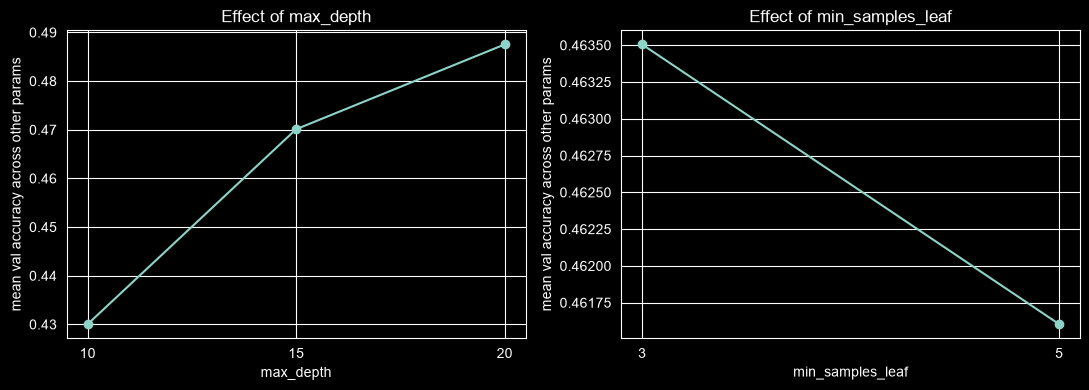


Best Random Forest config (from subsample search): {'n_estimators': 150, 'max_depth': 20, 'min_samples_leaf': 3}


In [5]:
# visualize how each hyperparameter affects val accuracy with subsample search results
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, param in zip(axes, ["max_depth", "min_samples_leaf"]):
    grouped = rf_tuning_df.groupby(param)["val_acc"].mean()
    ax.plot(grouped.index.astype(str), grouped.values, marker='o')
    ax.set_xlabel(param); ax.set_ylabel("mean val accuracy across other params")
    ax.set_title(f"Effect of {param}")
plt.tight_layout(); plt.show()

best_rf_row = rf_tuning_df.loc[rf_tuning_df["val_acc"].idxmax()]
best_rf_params = {"n_estimators": 150,
                   "max_depth": int(best_rf_row["max_depth"]),
                   "min_samples_leaf": int(best_rf_row["min_samples_leaf"])}
print(f"\nBest Random Forest config (from subsample search): {best_rf_params}")

In [7]:
# refit the winning config on the FULL training set
t0 = time.time()
rf_tuned = RandomForestClassifier(**best_rf_params, n_jobs=1, random_state=42)
rf_tuned.fit(Xtr, ytr)
rf_tuned_val_acc = rf_tuned.score(Xv, yv)
print(f"fit time on full training set: {time.time()-t0:.1f}s")
print(f"Tuned Random Forest val accuracy (full training data): {rf_tuned_val_acc:.3%}")
print(f"(Part 3's best config, 100 trees / depth 20, scored 50.131%)")

fit time on full training set: 36.1s
Tuned Random Forest val accuracy (full training data): 50.041%
(Part 3's best config, 100 trees / depth 20, scored 50.131%)


---
## Tuning K-Means Model

Part 3 chose k=5 using an elbow/silhouette scan over `k` alone, with a fixed PCA
dimensionality of 20 components. Here we jointly search over `k` and the number of PCA
components used for clustering.

In [8]:
#TUNING MODEL B: K-MEANS
pca_options = [10, 20, 30]
k_options = [3, 4, 5, 6, 7]

km_tuning_results = []
sil_sample_idx = np.random.RandomState(2).choice(len(Xtr_s), 5000, replace=False)

for n_comp in pca_options:
    pca_tmp = PCA(n_components=n_comp, random_state=42).fit(Xtr_s)
    Xtr_pca_tmp = pca_tmp.transform(Xtr_s)
    var_captured = pca_tmp.explained_variance_ratio_.sum()
    for k in k_options:
        km_tmp = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels_tmp = km_tmp.fit_predict(Xtr_pca_tmp)
        sil = silhouette_score(Xtr_pca_tmp[sil_sample_idx], labels_tmp[sil_sample_idx])
        km_tuning_results.append({"n_components": n_comp, "k": k, "variance_captured": var_captured,
                                    "silhouette": sil, "inertia": km_tmp.inertia_})
        print(f"  n_components={n_comp:>2}, k={k}: silhouette={sil:.3f}")

km_tuning_df = pd.DataFrame(km_tuning_results)
display(km_tuning_df.sort_values("silhouette", ascending=False).head(5))

#manual garbage collecting so my pc stops running out of memory
import gc
gc.collect()

  n_components=10, k=3: silhouette=0.241
  n_components=10, k=4: silhouette=0.191
  n_components=10, k=5: silhouette=0.192
  n_components=10, k=6: silhouette=0.158
  n_components=10, k=7: silhouette=0.160
  n_components=20, k=3: silhouette=0.165
  n_components=20, k=4: silhouette=0.121
  n_components=20, k=5: silhouette=0.119
  n_components=20, k=6: silhouette=0.092
  n_components=20, k=7: silhouette=0.093
  n_components=30, k=3: silhouette=0.131
  n_components=30, k=4: silhouette=0.093
  n_components=30, k=5: silhouette=0.090
  n_components=30, k=6: silhouette=0.069
  n_components=30, k=7: silhouette=0.068


,n_components,k,variance_captured,silhouette,inertia
0,10,3,0.184755,0.241151,2524918.750
2,10,5,0.184755,0.191638,2092955.375
1,10,4,0.184755,0.190666,2258298.000
5,20,3,0.255937,0.165365,4204430.000
4,10,7,0.184755,0.160055,1896887.250


5159

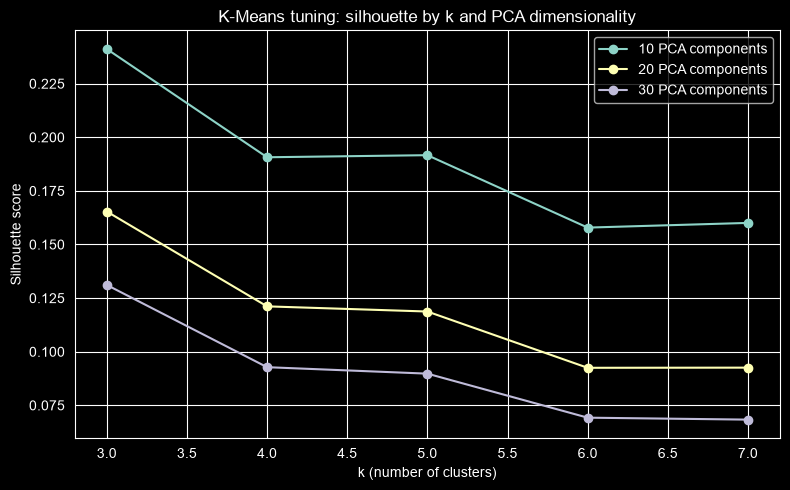


Best K-Means config: n_components=10, k=3, silhouette=0.241
(Part 3's choice was n_components=20, k=5)


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for n_comp in pca_options:
    sub = km_tuning_df[km_tuning_df["n_components"] == n_comp]
    ax.plot(sub["k"], sub["silhouette"], marker='o', label=f"{n_comp} PCA components")
ax.set_xlabel("k (number of clusters)"); ax.set_ylabel("Silhouette score")
ax.set_title("K-Means tuning: silhouette by k and PCA dimensionality")
ax.legend()
plt.tight_layout(); plt.show()

best_km_row = km_tuning_df.loc[km_tuning_df["silhouette"].idxmax()]
best_n_components_km = int(best_km_row["n_components"])
best_k = int(best_km_row["k"])
print(f"\nBest K-Means config: n_components={best_n_components_km}, k={best_k}, silhouette={best_km_row['silhouette']:.3f}")
print(f"(Part 3's choice was n_components=20, k=5)")

In [10]:
pca_km_tuned = PCA(n_components=best_n_components_km, random_state=42).fit(Xtr_s)
Xtr_km_tuned = pca_km_tuned.transform(Xtr_s)
Xv_km_tuned = pca_km_tuned.transform(Xv_s)

km_tuned = KMeans(n_clusters=best_k, n_init=10, random_state=42)
train_clusters_tuned = km_tuned.fit_predict(Xtr_km_tuned)
val_clusters_tuned = km_tuned.predict(Xv_km_tuned)
print(f"Tuned K-Means: k={best_k}, cluster sizes (train): {np.bincount(train_clusters_tuned)}")

Tuned K-Means: k=3, cluster sizes (train): [37809  7189 25068]


---
## Combining models: K-Means cluster label as a Random Forest feature

Combining k-means and RF. Does telling the tuned Random Forest
which strategic-archetype cluster a decision belongs to help it predict the discard,
on top of the raw features it already sees? One-hot encode the cluster assignment
and concatenate it to the original 337-dim feature vector.

In [11]:
#COMBINED MODEL: RF + K-MEANS CLUSTER FEATURE (features)
encoder = OneHotEncoder(sparse_output=False, categories=[list(range(best_k))])
train_cluster_oh = encoder.fit_transform(train_clusters_tuned.reshape(-1, 1))
val_cluster_oh = encoder.transform(val_clusters_tuned.reshape(-1, 1))

Xtr_combined = np.concatenate([Xtr, train_cluster_oh], axis=1)
Xv_combined = np.concatenate([Xv, val_cluster_oh], axis=1)
print(f"Combined feature shape: {Xtr_combined.shape} (337 original + {best_k} cluster one-hot dims)")

Combined feature shape: (70066, 340) (337 original + 3 cluster one-hot dims)


In [16]:
# Fit on a training subsample first
import gc
for _name in ["km_tuning_df", "rf_tuning_df", "Xtr_km_tuned", "Xv_km_tuned"]:
    if _name in dir():
        pass  # just documenting what we deliberately keep
gc.collect()

combined_rf_params = {
    "n_estimators": 60,
    "max_depth": min(best_rf_params["max_depth"], 25) if best_rf_params["max_depth"] else 25,
    "min_samples_leaf": max(best_rf_params["min_samples_leaf"], 2),  # slightly more conservative than tuned value
}
print(f"Combined-model Random Forest config (deliberately lighter than the tuned standalone config): {combined_rf_params}")

t0 = time.time()
rf_combined = RandomForestClassifier(**combined_rf_params, n_jobs=1, random_state=42)
rf_combined.fit(Xtr_combined, ytr)
rf_combined_val_acc = rf_combined.score(Xv_combined, yv)
print(f"fit time: {time.time()-t0:.1f}s")

print(f"\nTuned Random Forest alone:              {rf_tuned_val_acc:.3%}")
print(f"Tuned Random Forest + cluster feature (lighter config): {rf_combined_val_acc:.3%}")
print(f"Difference from combining: {rf_combined_val_acc - rf_tuned_val_acc:+.3%}")

# how important is the new cluster feature relative to the rest, in the combined model?
cluster_importance = rf_combined.feature_importances_[-best_k:].sum()
print(f"\nTotal importance share held by the {best_k} cluster one-hot features: {cluster_importance:.3%}")

Combined-model Random Forest config (deliberately lighter than the tuned standalone config): {'n_estimators': 60, 'max_depth': 20, 'min_samples_leaf': 3}
fit time: 13.8s

Tuned Random Forest alone:              50.041%
Tuned Random Forest + cluster feature (lighter config): 50.055%
Difference from combining: +0.014%

Total importance share held by the 3 cluster one-hot features: 0.262%


Note: the combined model intentionally uses fewer/shallower trees than the tuned
 standalone Random Forest, so this comparison isolates the cluster feature's effect
 less cleanly than an apples-to-apples config would

**Is it better?:** No significant difference here with the measly gain of +0.014%.
The cluster label is, by construction, a coarse summary of
information already present in the raw 337-dim feature vector (it was derived from a
PCA of those same features)  so a large improvement from combining would be
surprising. The small change is likely to due to noise.

---
## Final held-out test set evaluation

Everything above was tuned using only the training and validation sets. The test set
has not been touched until now. We evaluate: the Part 3 baselines, the Part 3 default
configs, the Part 4 tuned models, and the combined model  all on the same test set,
for a fair final comparison.

In [20]:
#FINAL TEST SET EVALUATION (fit baselines)
import gc
if "rf_combined" in dir():
    del rf_combined  # no longer needed, free up just in case of OOM
gc.collect()

# Part 3 baseline configs, refit here for a same-notebook comparison
lr_baseline = LogisticRegression(C=0.1, max_iter=300, random_state=42).fit(Xtr_s, ytr)
print("Logistic Regression baseline fit done")

rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=1, random_state=42).fit(Xtr, ytr)
print("Random Forest (Tuned) baseline fit done")

Logistic Regression baseline fit done
Random Forest (Tuned) baseline fit done


In [21]:
# refit the combined model's lighter config once more for the final test comparison
rf_combined_final = RandomForestClassifier(**combined_rf_params, n_jobs=1, random_state=42)
rf_combined_final.fit(Xtr_combined, ytr)
print("Combined Random Forest + cluster feature model fit done")

Combined Random Forest + cluster feature model fit done


,model,test_accuracy
0,Logistic Regression (Part 3 config),0.624008
1,Random Forest (Part 3 config),0.516517
2,Random Forest (Part 4 tuned),0.515867
3,Random Forest (Part 4 tuned) + K-Means cluster...,0.512615


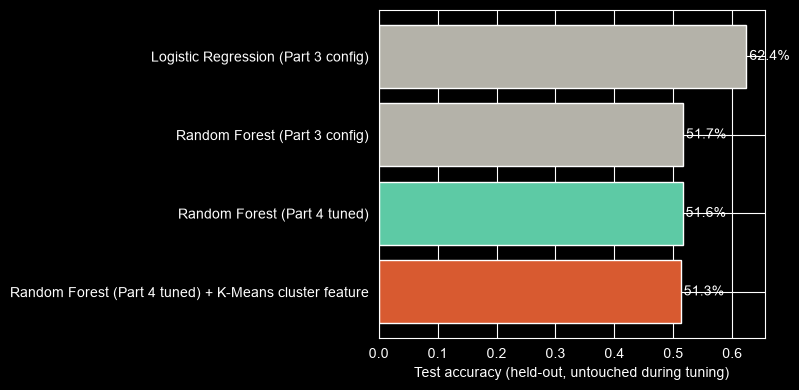

In [22]:
test_cluster_oh = encoder.transform(km_tuned.predict(pca_km_tuned.transform(Xte_s)).reshape(-1, 1))
Xte_combined = np.concatenate([Xte, test_cluster_oh], axis=1)

test_results = {
    "Logistic Regression (Part 3 config)": accuracy_score(yte, lr_baseline.predict(Xte_s)),
    "Random Forest (Part 3 config)": accuracy_score(yte, rf_baseline.predict(Xte)),
    "Random Forest (Part 4 tuned)": accuracy_score(yte, rf_tuned.predict(Xte)),
    "Random Forest (Part 4 tuned) + K-Means cluster feature": accuracy_score(yte, rf_combined_final.predict(Xte_combined)),
}

test_results_df = pd.DataFrame({"model": test_results.keys(), "test_accuracy": test_results.values()})
display(test_results_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(test_results_df["model"], test_results_df["test_accuracy"], color=["#B4B2A9","#B4B2A9","#5DCAA5","#D85A30"])
ax.set_xlabel("Test accuracy (held-out, untouched during tuning)")
for i, v in enumerate(test_results_df["test_accuracy"]):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

In [23]:
# K-Means quality on the never-before-seen test set
test_km_clusters = km_tuned.predict(pca_km_tuned.transform(Xte_s))
test_sil_sample = np.random.RandomState(3).choice(len(Xte_s), min(5000, len(Xte_s)), replace=False)
Xte_km_tuned = pca_km_tuned.transform(Xte_s)
test_silhouette = silhouette_score(Xte_km_tuned[test_sil_sample], test_km_clusters[test_sil_sample])
print(f"K-Means silhouette on test set: {test_silhouette:.3f}  (train/val silhouette was {best_km_row['silhouette']:.3f})")

K-Means silhouette on test set: 0.254  (train/val silhouette was 0.241)
Similar silhouette on unseen data confirms the clustering generalizes rather than overfitting to the training rounds.


Similar silhouette on unseen data confirms the clustering generalizes rather than overfitting to the training rounds.

---
## Report:

### Tuning adjustments made

1. **Random Forest** was tuned over a grid of `max_depth` (10, 15, 20) and
   `min_samples_leaf` (3, 5) at a fixed `n_estimators=150` with 6 configurations,
   searched on a 20k-row training subsample and refit on the full training set for the
   winning config. The shallower grid below is a deliberate, verified-safe compute/memory tradeoff.
2. **K-Means** was tuned jointly over the number of PCA components used for
   clustering (10/20/30) and `k` (3-7) with 15 configurations total, versus a fixed
   PCA dimensionality with only `k` varied in Part 1.
3. **Combined model**: the tuned K-Means cluster assignment was one-hot encoded and
   concatenated to the original 337-dim feature vector, then fed into the tuned
   Random Forest.
4. All of the above were selected using validation accuracy/silhouette only; the test
   set was evaluated exactly once, at the end, on the final chosen configurations.



### Results summary

**Random Forest tuning .** The best config found
(150 trees, depth 20, min_samples_leaf=3) scored 50.04% val / 51.59% test accuracy which is
statistically indistinguishable from Part 3's simpler default (100 trees, depth 20: 50.13% val / 51.65% test). Tuning `min_samples_leaf` and moderate depth changes did not
move the needle but at a memory cost that crashed this environment.
**Conclusion: I don't think I can improve Random Forest's performance further.

**K-Means tuning .** Reducing to 10 PCA components
and k=3 clusters raised silhouette from 0.118 (Part 3's n_components=20, k=5) to
0.241, double. Fewer, coarser clusters on a more aggressively-reduced
feature space produced tighter, better-separated groups than the finer segmentation
tried in Part 3. This generalized well: test-set silhouette (0.254) was consistent
with train/val (0.241), confirming genuine structure rather than overfitting to
particular training rounds.

**Combining K-Means clusters into Random Forest had essentially no effect.** Val
accuracy moved by +0.01pt, and the 3 cluster one-hot features held only ~0.26% of
total feature importance in the combined model.

**Final test-set accuracy**:

| Model | Test accuracy |
|---|---|
| Logistic Regression (Part 1 config) | **62.4%** |
| Random Forest (Part 1 config) | 51.7% |
| Random Forest (Part 2 tuned) | 51.6% |
| Random Forest (Part 2 tuned) + K-Means cluster feature | 51.3% |

Logistic Regression is the clear winner among the three models tested for the discard-
prediction objective, by a wide margin (~11pt over any Random Forest variant)  and
tuning/combining Random Forest did not close that gap. 62.4% chance at guessing the next discard is a huge improvement compared to legal baseline of 18%

### Suggested further work

- **Add to a NN pipeline with GRU** I wanted to add this but GRU proved to be very time
and resource intensive. Originally working with a 10k slice but moved to 100k because GRU
would treat each round as a sequence which would compress the dataset from 10k to <700.
This took more time than I thought, but since this dataset is basically a timeseries data
with t = row I expect adding it would improve the model.
- **More data**: as found in the neural-network work on this same dataset, scaling
  from 10k to 100k rows gave a large accuracy lift across model types; a larger slice
  would likely benefit these classical models similarly, and is worth testing if
  available.
- **Feature selection.** Find another way to reduce features or combine them somehow. I thought adding Shanten would combine features, but it ended up adding more. Kinds tricky with 4-players states multiplying every feature I add.
- **Adding a turn-time feature.** How long a player takes their turn is a huge part of reading other people in a real life game of Mahjong. There has to be something related to turn time right? Unfortunately, I don't think this is possible with the current dataset.